### Preprocessing Step 2


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [38]:
# Importing the dataset
df = pd.read_csv('D:/sgk62/Documents/Master of AI/AML/Assignment Data/Microsoft Security Incident Prediction/DF_Sample_10K.csv')

In [39]:
df

,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,...,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City,Usage
0,352187323006,295,461,6425,2024-06-03T08:00:34.000Z,1,1,InitialAccess,T1566.002,FalsePositive,...,NaN,5,66,NaN,NaN,Malicious,242,1445,10630,Public
1,446676599085,11,432098,828650,2024-06-13T12:35:51.000Z,4,3,InitialAccess,NaN,FalsePositive,...,NaN,5,66,NaN,NaN,NaN,8,6,3,NaN
2,721554509327,136,135902,1237978,2024-06-13T19:59:08.000Z,0,0,InitialAccess,T1078;T1078.004,BenignPositive,...,NaN,5,66,NaN,NaN,NaN,242,1445,10630,NaN
3,816043788088,0,200,167682,2024-06-07T20:03:40.000Z,0,0,InitialAccess,T1078;T1078.004,TruePositive,...,NaN,5,66,NaN,NaN,NaN,242,1445,10630,Public
4,1082331760266,1,283,521129,2024-06-02T12:27:48.000Z,14,12,CredentialAccess,T1110;T1110.003;T1110.001,TruePositive,...,NaN,5,66,NaN,NaN,NaN,242,1445,10630,Private
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13660,128849018936,67,146235,45596,2024-06-09T01:54:16.000Z,1,1,InitialAccess,T1566.002,BenignPositive,...,NaN,5,66,Inbound,NaN,NoThreatsFound,242,1445,10630,NaN
13661,670014901898,148,20,215301,2024-06-04T05:54:12.000Z,124,35549,Exfiltration,NaN,TruePositive,...,NaN,5,66,NaN,NaN,NaN,242,1445,10630,NaN
13662,103079216945,134,71254,58674,2024-06-11T17:27:00.000Z,6,5,InitialAccess,T1566,BenignPositive,...,NaN,5,66,NaN,NaN,NoThreatsFound,242,1445,10630,NaN
13663,283467842921,65,773,2069,2024-06-04T19:09:50.000Z,35,23,InitialAccess,T1566,TruePositive,...,NaN,5,66,NaN,NaN,NaN,242,1445,10630,NaN


In [40]:
df.shape

(13665, 46)

In [41]:
df.dtypes

Id                      int64
OrgId                   int64
IncidentId              int64
AlertId                 int64
Timestamp              object
DetectorId              int64
AlertTitle              int64
Category               object
MitreTechniques        object
IncidentGrade          object
ActionGrouped          object
ActionGranular         object
EntityType             object
EvidenceRole           object
DeviceId                int64
Sha256                  int64
IpAddress               int64
Url                     int64
AccountSid              int64
AccountUpn              int64
AccountObjectId         int64
AccountName             int64
DeviceName              int64
NetworkMessageId        int64
EmailClusterId        float64
RegistryKey             int64
RegistryValueName       int64
RegistryValueData       int64
ApplicationId           int64
ApplicationName         int64
OAuthApplicationId      int64
ThreatFamily           object
FileName                int64
FolderPath

In [42]:
df.isnull().sum() # Detect missing values

Id                        0
OrgId                     0
IncidentId                0
AlertId                   0
Timestamp                 0
DetectorId                0
AlertTitle                0
Category                  0
MitreTechniques        7809
IncidentGrade            59
ActionGrouped         13595
ActionGranular        13595
EntityType                0
EvidenceRole              0
DeviceId                  0
Sha256                    0
IpAddress                 0
Url                       0
AccountSid                0
AccountUpn                0
AccountObjectId           0
AccountName               0
DeviceName                0
NetworkMessageId          0
EmailClusterId        13514
RegistryKey               0
RegistryValueName         0
RegistryValueData         0
ApplicationId             0
ApplicationName           0
OAuthApplicationId        0
ThreatFamily          13548
FileName                  0
FolderPath                0
ResourceIdName            0
ResourceType        

In [43]:
100 * df.isnull().sum() / len(df)

Id                     0.000000
OrgId                  0.000000
IncidentId             0.000000
AlertId                0.000000
Timestamp              0.000000
DetectorId             0.000000
AlertTitle             0.000000
Category               0.000000
MitreTechniques       57.145993
IncidentGrade          0.431760
ActionGrouped         99.487742
ActionGranular        99.487742
EntityType             0.000000
EvidenceRole           0.000000
DeviceId               0.000000
Sha256                 0.000000
IpAddress              0.000000
Url                    0.000000
AccountSid             0.000000
AccountUpn             0.000000
AccountObjectId        0.000000
AccountName            0.000000
DeviceName             0.000000
NetworkMessageId       0.000000
EmailClusterId        98.894987
RegistryKey            0.000000
RegistryValueName      0.000000
RegistryValueData      0.000000
ApplicationId          0.000000
ApplicationName        0.000000
OAuthApplicationId     0.000000
ThreatFa

In [44]:
df.describe()

,Id,OrgId,IncidentId,AlertId,DetectorId,AlertTitle,DeviceId,Sha256,IpAddress,Url,...,ApplicationName,OAuthApplicationId,FileName,FolderPath,ResourceIdName,OSFamily,OSVersion,CountryCode,State,City
count,1.366500e+04,13665.000000,13665.000000,1.366500e+04,13665.000000,13665.000000,13665.000000,13665.000000,13665.000000,13665.000000,...,13665.000000,13665.000000,13665.000000,13665.000000,13665.000000,13665.000000,13665.000000,13665.000000,13665.000000,13665.000000
mean,8.465690e+11,176.802269,69153.076473,4.080001e+05,109.589316,2842.370435,95459.639444,129312.301647,284762.304427,150302.569265,...,3346.054446,880.820271,263606.992902,107927.048591,3584.091694,4.893377,64.583974,223.399854,1348.889279,9919.981851
std,4.981655e+11,377.905513,120226.591359,4.635479e+05,432.730662,11452.490766,16867.339137,32957.908702,142149.337371,37593.912021,...,499.594216,11.825182,79510.751647,31774.587227,75.762137,0.720215,9.551873,63.388663,356.111946,2634.221471
min,4.170000e+02,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.209068e+11,9.000000,479.000000,2.116600e+04,2.000000,2.000000,98799.000000,138268.000000,360606.000000,160396.000000,...,3421.000000,881.000000,289573.000000,117668.000000,3586.000000,5.000000,66.000000,242.000000,1445.000000,10630.000000
50%,8.332237e+11,43.000000,9460.000000,2.113690e+05,9.000000,11.000000,98799.000000,138268.000000,360606.000000,160396.000000,...,3421.000000,881.000000,289573.000000,117668.000000,3586.000000,5.000000,66.000000,242.000000,1445.000000,10630.000000
75%,1.279900e+12,171.000000,80530.000000,6.781500e+05,44.000000,158.000000,98799.000000,138268.000000,360606.000000,160396.000000,...,3421.000000,881.000000,289573.000000,117668.000000,3586.000000,5.000000,66.000000,242.000000,1445.000000,10630.000000
max,1.709397e+12,5931.000000,599329.000000,1.719565e+06,8448.000000,111748.000000,98799.000000,138268.000000,360606.000000,160396.000000,...,3421.000000,881.000000,289573.000000,117668.000000,3586.000000,5.000000,66.000000,242.000000,1445.000000,10630.000000


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import shapiro, kstest, anderson

In [46]:
#Step 1: Split the values
df['MitreTechniques'] = df['MitreTechniques'].str.split(';')

# Step 2: Expand the DataFrame
df = df.explode('MitreTechniques')
# # Step 3: Remove duplicates df.drop_duplicates(inplace=True)

In [47]:
df.dtypes

Id                      int64
OrgId                   int64
IncidentId              int64
AlertId                 int64
Timestamp              object
DetectorId              int64
AlertTitle              int64
Category               object
MitreTechniques        object
IncidentGrade          object
ActionGrouped          object
ActionGranular         object
EntityType             object
EvidenceRole           object
DeviceId                int64
Sha256                  int64
IpAddress               int64
Url                     int64
AccountSid              int64
AccountUpn              int64
AccountObjectId         int64
AccountName             int64
DeviceName              int64
NetworkMessageId        int64
EmailClusterId        float64
RegistryKey             int64
RegistryValueName       int64
RegistryValueData       int64
ApplicationId           int64
ApplicationName         int64
OAuthApplicationId      int64
ThreatFamily           object
FileName                int64
FolderPath

In [48]:
# # Convert float64 to object
df['EmailClusterId'] = df['EmailClusterId'].astype('object')

# Check the data type after conversion
print(df['EmailClusterId'].dtype) # Output: object

object


In [49]:
duplicates = df[df.duplicated()]
print("Duplicate rows:\n", duplicates)


Duplicate rows:
 Empty DataFrame
Columns: [Id, OrgId, IncidentId, AlertId, Timestamp, DetectorId, AlertTitle, Category, MitreTechniques, IncidentGrade, ActionGrouped, ActionGranular, EntityType, EvidenceRole, DeviceId, Sha256, IpAddress, Url, AccountSid, AccountUpn, AccountObjectId, AccountName, DeviceName, NetworkMessageId, EmailClusterId, RegistryKey, RegistryValueName, RegistryValueData, ApplicationId, ApplicationName, OAuthApplicationId, ThreatFamily, FileName, FolderPath, ResourceIdName, ResourceType, Roles, OSFamily, OSVersion, AntispamDirection, SuspicionLevel, LastVerdict, CountryCode, State, City, Usage]
Index: []

[0 rows x 46 columns]


In [50]:
df_cleaned = df.drop_duplicates()
print("\nDataFrame after removing duplicates:\n", df_cleaned)



DataFrame after removing duplicates:
                  Id  OrgId  IncidentId  AlertId                 Timestamp  \
0      352187323006    295         461     6425  2024-06-03T08:00:34.000Z   
1      446676599085     11      432098   828650  2024-06-13T12:35:51.000Z   
2      721554509327    136      135902  1237978  2024-06-13T19:59:08.000Z   
2      721554509327    136      135902  1237978  2024-06-13T19:59:08.000Z   
3      816043788088      0         200   167682  2024-06-07T20:03:40.000Z   
...             ...    ...         ...      ...                       ...   
13660  128849018936     67      146235    45596  2024-06-09T01:54:16.000Z   
13661  670014901898    148          20   215301  2024-06-04T05:54:12.000Z   
13662  103079216945    134       71254    58674  2024-06-11T17:27:00.000Z   
13663  283467842921     65         773     2069  2024-06-04T19:09:50.000Z   
13664  987842482916     38      289600   686922  2024-06-14T17:08:07.000Z   

       DetectorId  AlertTitle       

In [51]:
from sklearn.impute import SimpleImputer

# Assuming df is your DataFrame and these are the columns you want to impute
columns_to_impute = [
    'MitreTechniques', 'IncidentGrade', 'ActionGrouped', 'ActionGranular', 
    'EmailClusterId', 'ThreatFamily', 'ResourceType', 'Roles', 
    'AntispamDirection', 'SuspicionLevel', 'LastVerdict', 'Usage'
]

# Initialize the SimpleImputer for 'most_frequent' strategy
imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

for column in columns_to_impute:
    # Fit and transform the imputer on each column
    df[[column]] = imputer.fit_transform(df[[column]])

# Check the DataFrame after imputation
print(df)


                 Id  OrgId  IncidentId  AlertId                 Timestamp  \
0      352187323006    295         461     6425  2024-06-03T08:00:34.000Z   
1      446676599085     11      432098   828650  2024-06-13T12:35:51.000Z   
2      721554509327    136      135902  1237978  2024-06-13T19:59:08.000Z   
2      721554509327    136      135902  1237978  2024-06-13T19:59:08.000Z   
3      816043788088      0         200   167682  2024-06-07T20:03:40.000Z   
...             ...    ...         ...      ...                       ...   
13660  128849018936     67      146235    45596  2024-06-09T01:54:16.000Z   
13661  670014901898    148          20   215301  2024-06-04T05:54:12.000Z   
13662  103079216945    134       71254    58674  2024-06-11T17:27:00.000Z   
13663  283467842921     65         773     2069  2024-06-04T19:09:50.000Z   
13664  987842482916     38      289600   686922  2024-06-14T17:08:07.000Z   

       DetectorId  AlertTitle           Category MitreTechniques  \
0      

In [52]:
100 * df.isnull().sum() / len(df)

Id                    0.0
OrgId                 0.0
IncidentId            0.0
AlertId               0.0
Timestamp             0.0
DetectorId            0.0
AlertTitle            0.0
Category              0.0
MitreTechniques       0.0
IncidentGrade         0.0
ActionGrouped         0.0
ActionGranular        0.0
EntityType            0.0
EvidenceRole          0.0
DeviceId              0.0
Sha256                0.0
IpAddress             0.0
Url                   0.0
AccountSid            0.0
AccountUpn            0.0
AccountObjectId       0.0
AccountName           0.0
DeviceName            0.0
NetworkMessageId      0.0
EmailClusterId        0.0
RegistryKey           0.0
RegistryValueName     0.0
RegistryValueData     0.0
ApplicationId         0.0
ApplicationName       0.0
OAuthApplicationId    0.0
ThreatFamily          0.0
FileName              0.0
FolderPath            0.0
ResourceIdName        0.0
ResourceType          0.0
Roles                 0.0
OSFamily              0.0
OSVersion   

In [53]:

# Convert the 'Timestamp' column to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Convert to timestamp (seconds since epoch)
df['Timestamp'] = df['Timestamp'].astype(int) / 10**9

print(df)


                 Id  OrgId  IncidentId  AlertId     Timestamp  DetectorId  \
0      352187323006    295         461     6425  1.717402e+09           1   
1      446676599085     11      432098   828650  1.718282e+09           4   
2      721554509327    136      135902  1237978  1.718309e+09           0   
2      721554509327    136      135902  1237978  1.718309e+09           0   
3      816043788088      0         200   167682  1.717791e+09           0   
...             ...    ...         ...      ...           ...         ...   
13660  128849018936     67      146235    45596  1.717898e+09           1   
13661  670014901898    148          20   215301  1.717480e+09         124   
13662  103079216945    134       71254    58674  1.718127e+09           6   
13663  283467842921     65         773     2069  1.717528e+09          35   
13664  987842482916     38      289600   686922  1.718385e+09           2   

       AlertTitle           Category MitreTechniques   IncidentGrade  ...  

In [54]:
from sklearn.preprocessing import LabelEncoder

# List of columns to encode including the target variable
columns_to_label_encode = ['Category', 'MitreTechniques', 'ActionGrouped','EmailClusterId', 
                           'ActionGranular', 'EntityType', 'EvidenceRole', 
                           'ResourceType', 'Roles', 'AntispamDirection', 
                           'SuspicionLevel', 'LastVerdict', 'Usage', 'ThreatFamily','IncidentGrade']

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Apply label encoding to each column
for column in columns_to_label_encode:
    df[column] = label_encoder.fit_transform(df[column].astype(str))

# Display the DataFrame after encoding
print(df[columns_to_label_encode].head())

   Category  MitreTechniques  ActionGrouped  EmailClusterId  ActionGranular  \
0         9              209              0              31               5   
1         9               77              0              31               5   
2         9               77              0              31               5   
2         9               80              0              31               5   
3         9               77              0              31               5   

   EntityType  EvidenceRole  ResourceType  Roles  AntispamDirection  \
0          19             1             0      2                  0   
1           8             1             0      2                  0   
2          20             0             0      2                  0   
2          20             0             0      2                  0   
3          20             0             0      2                  0   

   SuspicionLevel  LastVerdict  Usage  ThreatFamily  IncidentGrade  
0               1            

In [55]:
df.dtypes

Id                      int64
OrgId                   int64
IncidentId              int64
AlertId                 int64
Timestamp             float64
DetectorId              int64
AlertTitle              int64
Category                int64
MitreTechniques         int64
IncidentGrade           int64
ActionGrouped           int64
ActionGranular          int64
EntityType              int64
EvidenceRole            int64
DeviceId                int64
Sha256                  int64
IpAddress               int64
Url                     int64
AccountSid              int64
AccountUpn              int64
AccountObjectId         int64
AccountName             int64
DeviceName              int64
NetworkMessageId        int64
EmailClusterId          int64
RegistryKey             int64
RegistryValueName       int64
RegistryValueData       int64
ApplicationId           int64
ApplicationName         int64
OAuthApplicationId      int64
ThreatFamily            int64
FileName                int64
FolderPath

In [56]:
# Retrieve the mapping for target variable
mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Encoding Mapping:")
print(mapping)


Label Encoding Mapping:
{'BenignPositive': np.int64(0), 'FalsePositive': np.int64(1), 'TruePositive': np.int64(2)}


In [57]:
# Define the target variable
y = df['IncidentGrade']

# Define the features by selecting all columns except the target
X = df.drop(columns=['IncidentGrade'])



In [58]:
import statsmodels.api as sm
X2 = sm.add_constant(X)
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:          IncidentGrade   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.316
Method:                 Least Squares   F-statistic:                     185.9
Date:                Mon, 30 Dec 2024   Prob (F-statistic):               0.00
Time:                        20:14:36   Log-Likelihood:                -19394.
No. Observations:               17598   AIC:                         3.888e+04
Df Residuals:                   17553   BIC:                         3.923e+04
Df Model:                          44                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                9.28e-05   2.74

In [59]:
X = X.drop(columns=['OSFamily', 'OSVersion', 'Usage', 'SuspicionLevel','Roles', 'OSFamily', 
                    'OSVersion', 'AntispamDirection', 'ResourceType', 'ResourceIdName', 'FolderPath',
                      'OAuthApplicationId', 'RegistryValueData', 'RegistryKey', 'AccountName','DeviceId' ])

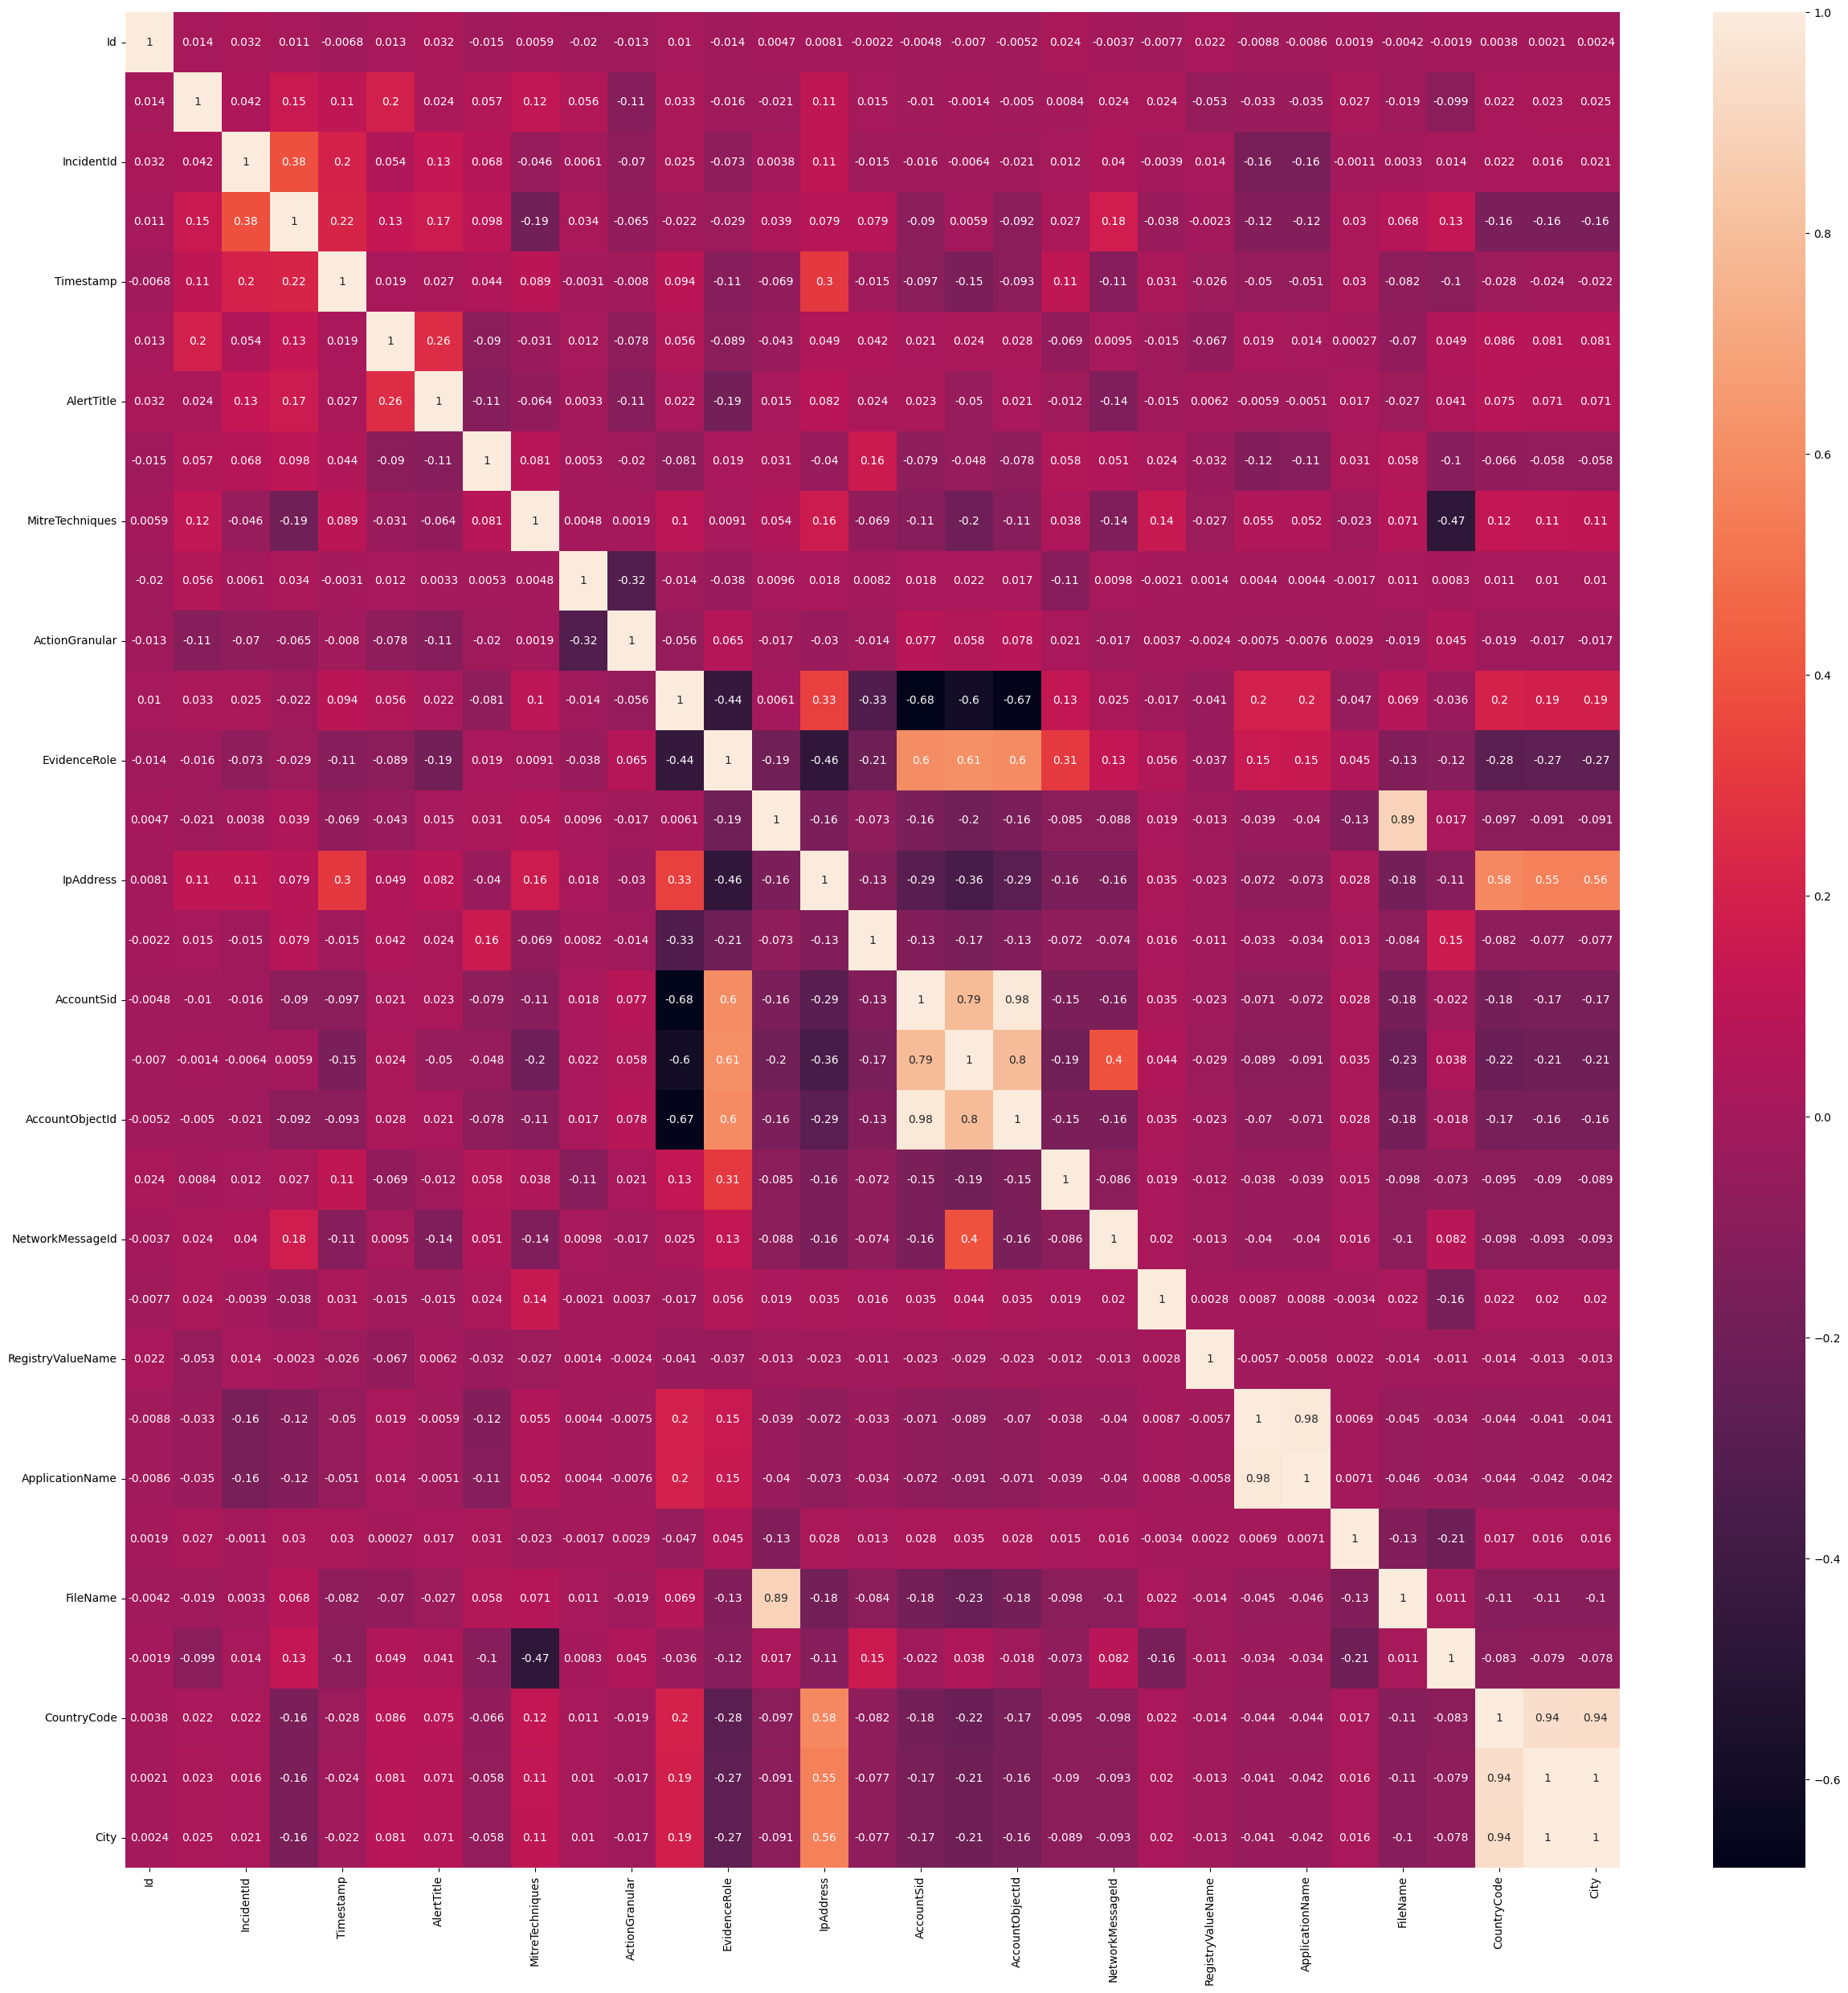

In [60]:
sns.heatmap(X.corr(), annot = True)
fig = plt.gcf()
fig.set_size_inches(30,30)

In [61]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assuming 'X' is your DataFrame of predictors
def calculate_vif(X):
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif

# Example usage
vif_df = calculate_vif(X)
print(vif_df)

             Variable         VIF
0                  Id    1.004746
1               OrgId    1.125034
2          IncidentId    1.235452
3             AlertId    1.558099
4           Timestamp    0.000146
5          DetectorId    1.182642
6          AlertTitle    1.245648
7            Category    1.120837
8     MitreTechniques    1.498370
9       ActionGrouped    1.134506
10     ActionGranular    1.163531
11         EntityType    3.906486
12       EvidenceRole    4.165887
13             Sha256    5.709852
14          IpAddress    2.541634
15                Url    2.251837
16         AccountSid   34.057060
17         AccountUpn   12.856324
18    AccountObjectId   35.622248
19         DeviceName    1.956812
20   NetworkMessageId    4.675072
21     EmailClusterId    1.061157
22  RegistryValueName    1.037824
23      ApplicationId   28.838129
24    ApplicationName   28.734818
25       ThreatFamily    1.094305
26           FileName    5.871429
27        LastVerdict    1.472430
28        Coun

In [62]:
X = X.drop(['State', 'ApplicationId','AccountSid', 'AccountUpn', 'FileName', 'AccountObjectId'], axis=1) # Drop columns with high VIF 'State', ApplicationId','AccountSid', AccountUpn', 'FileName', 'AccountObjectId'

# Recalculate VIF for the reduced dataset
vif_reduced = calculate_vif(X)
print(vif_reduced)

             Variable       VIF
0                  Id  1.004244
1               OrgId  1.116696
2          IncidentId  1.221529
3             AlertId  1.511634
4           Timestamp  0.000124
5          DetectorId  1.161266
6          AlertTitle  1.222572
7            Category  1.107661
8     MitreTechniques  1.433385
9       ActionGrouped  1.133403
10     ActionGranular  1.158154
11         EntityType  2.422352
12       EvidenceRole  3.224516
13             Sha256  1.313694
14          IpAddress  2.408857
15                Url  1.793868
16         DeviceName  1.426240
17   NetworkMessageId  1.213600
18     EmailClusterId  1.049799
19  RegistryValueName  1.026357
20    ApplicationName  1.298022
21       ThreatFamily  1.090907
22        LastVerdict  1.470711
23        CountryCode  9.053043
24               City  8.636466


In [63]:
from scipy.stats import kstest

# Kolmogorov-Smirnov Test
for column in X.columns:
    stat, p = kstest(X[column], 'norm')
    print(f'{column}: Statistics={stat:.3f}, p={p:.3f}')
    if p > 0.05:
        print(f'{column} looks normally distributed (fail to reject H0)\n')
    else:
        print(f'{column} does not look normally distributed (reject H0)\n')


Id: Statistics=1.000, p=0.000
Id does not look normally distributed (reject H0)

OrgId: Statistics=0.826, p=0.000
OrgId does not look normally distributed (reject H0)

IncidentId: Statistics=0.994, p=0.000
IncidentId does not look normally distributed (reject H0)

AlertId: Statistics=0.997, p=0.000
AlertId does not look normally distributed (reject H0)

Timestamp: Statistics=1.000, p=0.000
Timestamp does not look normally distributed (reject H0)

DetectorId: Statistics=0.698, p=0.000
DetectorId does not look normally distributed (reject H0)

AlertTitle: Statistics=0.698, p=0.000
AlertTitle does not look normally distributed (reject H0)

Category: Statistics=0.886, p=0.000
Category does not look normally distributed (reject H0)

MitreTechniques: Statistics=1.000, p=0.000
MitreTechniques does not look normally distributed (reject H0)

ActionGrouped: Statistics=0.500, p=0.000
ActionGrouped does not look normally distributed (reject H0)

ActionGranular: Statistics=0.997, p=0.000
ActionGran

In [64]:
# Example data (replace this with your actual data)
# y = pd.Series(...)
# y = pd.DataFrame(...)

# Check type
if isinstance(y, pd.Series):
    print("y is a Series")
elif isinstance(y, pd.DataFrame):
    print("y is a DataFrame")
else:
    print("y is neither a Series nor a DataFrame")


y is a Series


In [65]:
# Value Counts
y.value_counts()

IncidentGrade
0    6970
2    6721
1    3907
Name: count, dtype: int64

<Axes: xlabel='IncidentGrade', ylabel='count'>

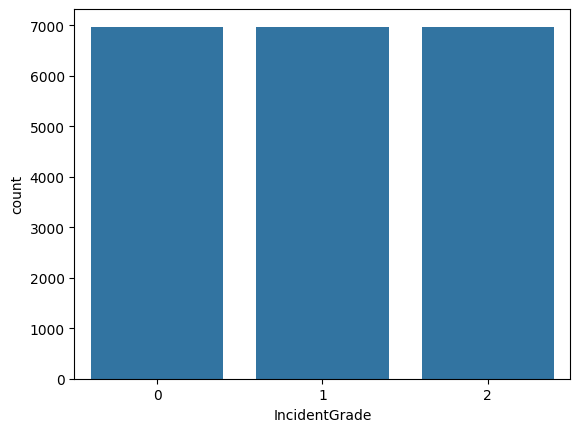

In [66]:
from imblearn.over_sampling import SMOTE

x_b, y_b = SMOTE().fit_resample(X, y)
sns.countplot(x = y_b)

In [68]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the scaler on the features
X_scaled = scaler.fit_transform(x_b)

# Convert the scaled features back to a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=x_b.columns)

# Ensure indices match 
y.reset_index(drop=True, inplace=True)
X_scaled.reset_index(drop=True, inplace=True)

# Display the scaled features
print(X_scaled.head())

         Id     OrgId  IncidentId   AlertId  Timestamp  DetectorId  \
0  0.206030  0.049739    0.000769  0.003736   0.586498    0.000118   
1  0.261307  0.001855    0.720970  0.481895   0.885177    0.000473   
2  0.422111  0.022930    0.226757  0.719937   0.894199    0.000000   
3  0.422111  0.022930    0.226757  0.719937   0.894199    0.000000   
4  0.477387  0.000000    0.000334  0.097514   0.718445    0.000000   

   AlertTitle  Category  MitreTechniques  ActionGrouped  ...       Url  \
0    0.000009    0.5625         0.889362            0.0  ...  0.405365   
1    0.000027    0.5625         0.327660            0.0  ...  1.000000   
2    0.000000    0.5625         0.327660            0.0  ...  1.000000   
3    0.000000    0.5625         0.340426            0.0  ...  1.000000   
4    0.000000    0.5625         0.327660            0.0  ...  1.000000   

   DeviceName  NetworkMessageId  EmailClusterId  RegistryValueName  \
0         1.0               1.0        0.213793                1

In [69]:
X_scaled

,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,ActionGrouped,...,Url,DeviceName,NetworkMessageId,EmailClusterId,RegistryValueName,ApplicationName,ThreatFamily,LastVerdict,CountryCode,City
0,0.206030,0.049739,0.000769,0.003736,0.586498,0.000118,0.000009,0.5625,0.889362,0.0,...,0.405365,1.0,1.0,0.213793,1.0,1.0,0.232877,0.0,1.000000,1.000000
1,0.261307,0.001855,0.720970,0.481895,0.885177,0.000473,0.000027,0.5625,0.327660,0.0,...,1.000000,1.0,1.0,0.213793,1.0,1.0,0.232877,1.0,0.033058,0.000282
2,0.422111,0.022930,0.226757,0.719937,0.894199,0.000000,0.000000,0.5625,0.327660,0.0,...,1.000000,1.0,1.0,0.213793,1.0,1.0,0.232877,1.0,1.000000,1.000000
3,0.422111,0.022930,0.226757,0.719937,0.894199,0.000000,0.000000,0.5625,0.340426,0.0,...,1.000000,1.0,1.0,0.213793,1.0,1.0,0.232877,1.0,1.000000,1.000000
4,0.477387,0.000000,0.000334,0.097514,0.718445,0.000000,0.000000,0.5625,0.327660,0.0,...,1.000000,1.0,1.0,0.213793,1.0,1.0,0.232877,1.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20905,0.407035,0.016186,0.001463,0.025169,0.655717,0.000000,0.000000,0.5625,0.659574,0.0,...,1.000000,1.0,1.0,0.213793,1.0,1.0,0.232877,0.0,1.000000,1.000000
20906,0.753769,0.009442,0.042898,0.659267,0.755525,0.000000,0.000000,0.5625,0.336170,0.0,...,1.000000,1.0,1.0,0.213793,1.0,1.0,0.232877,1.0,1.000000,1.000000
20907,0.100503,0.014163,0.000574,0.646035,0.633835,0.010772,0.000698,0.5625,0.693617,0.0,...,1.000000,1.0,1.0,0.213793,1.0,1.0,0.232877,1.0,1.000000,1.000000
20908,0.889447,0.000000,0.000162,0.761881,0.779848,0.000355,0.000018,0.5625,0.327660,0.0,...,1.000000,1.0,1.0,0.213793,1.0,1.0,0.232877,1.0,1.000000,1.000000


In [70]:
# Value Counts
y_b.value_counts()

IncidentGrade
1    6970
0    6970
2    6970
Name: count, dtype: int64

In [71]:
X_scaled.shape

(20910, 25)

In [72]:
# Save X to a CSV file
X_scaled.to_csv(r'D:\sgk62\Documents\Master of AI\AML\Assignment Data\X_preprocessed_10K_RemovedMorefeature_1.csv', index=False)

# Save y to a CSV file
y_b.to_csv(r'D:\sgk62\Documents\Master of AI\AML\Assignment Data\y_preprocessed_10K_RemovedMoreFeature_1.csv', index=False, header=True)
